/tmp/ipykernel_2549/588143879.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-717.510071,201.575790,-146.332916,97.249215,17882,20.160772
2,-489.149017,246.958984,-99.649287,105.045741,17660,19.910482
3,-388.092255,315.717041,-67.171641,112.301877,17692,19.946560
4,-352.806122,423.271515,-27.724965,117.427379,17660,19.910482
5,-306.741425,991.209473,63.055285,134.376953,17803,20.071705


Returns Analysis


,1D,5D,10D
Ann. alpha,0.490,0.405,0.316
beta,-0.004,-0.003,0.017
Mean Period Wise Return Top Quantile (bps),22.691,18.293,13.533
Mean Period Wise Return Bottom Quantile (bps),-9.292,-9.916,-9.248
Mean Period Wise Spread (bps),31.983,27.559,22.182


<Figure size 640x480 with 0 Axes>

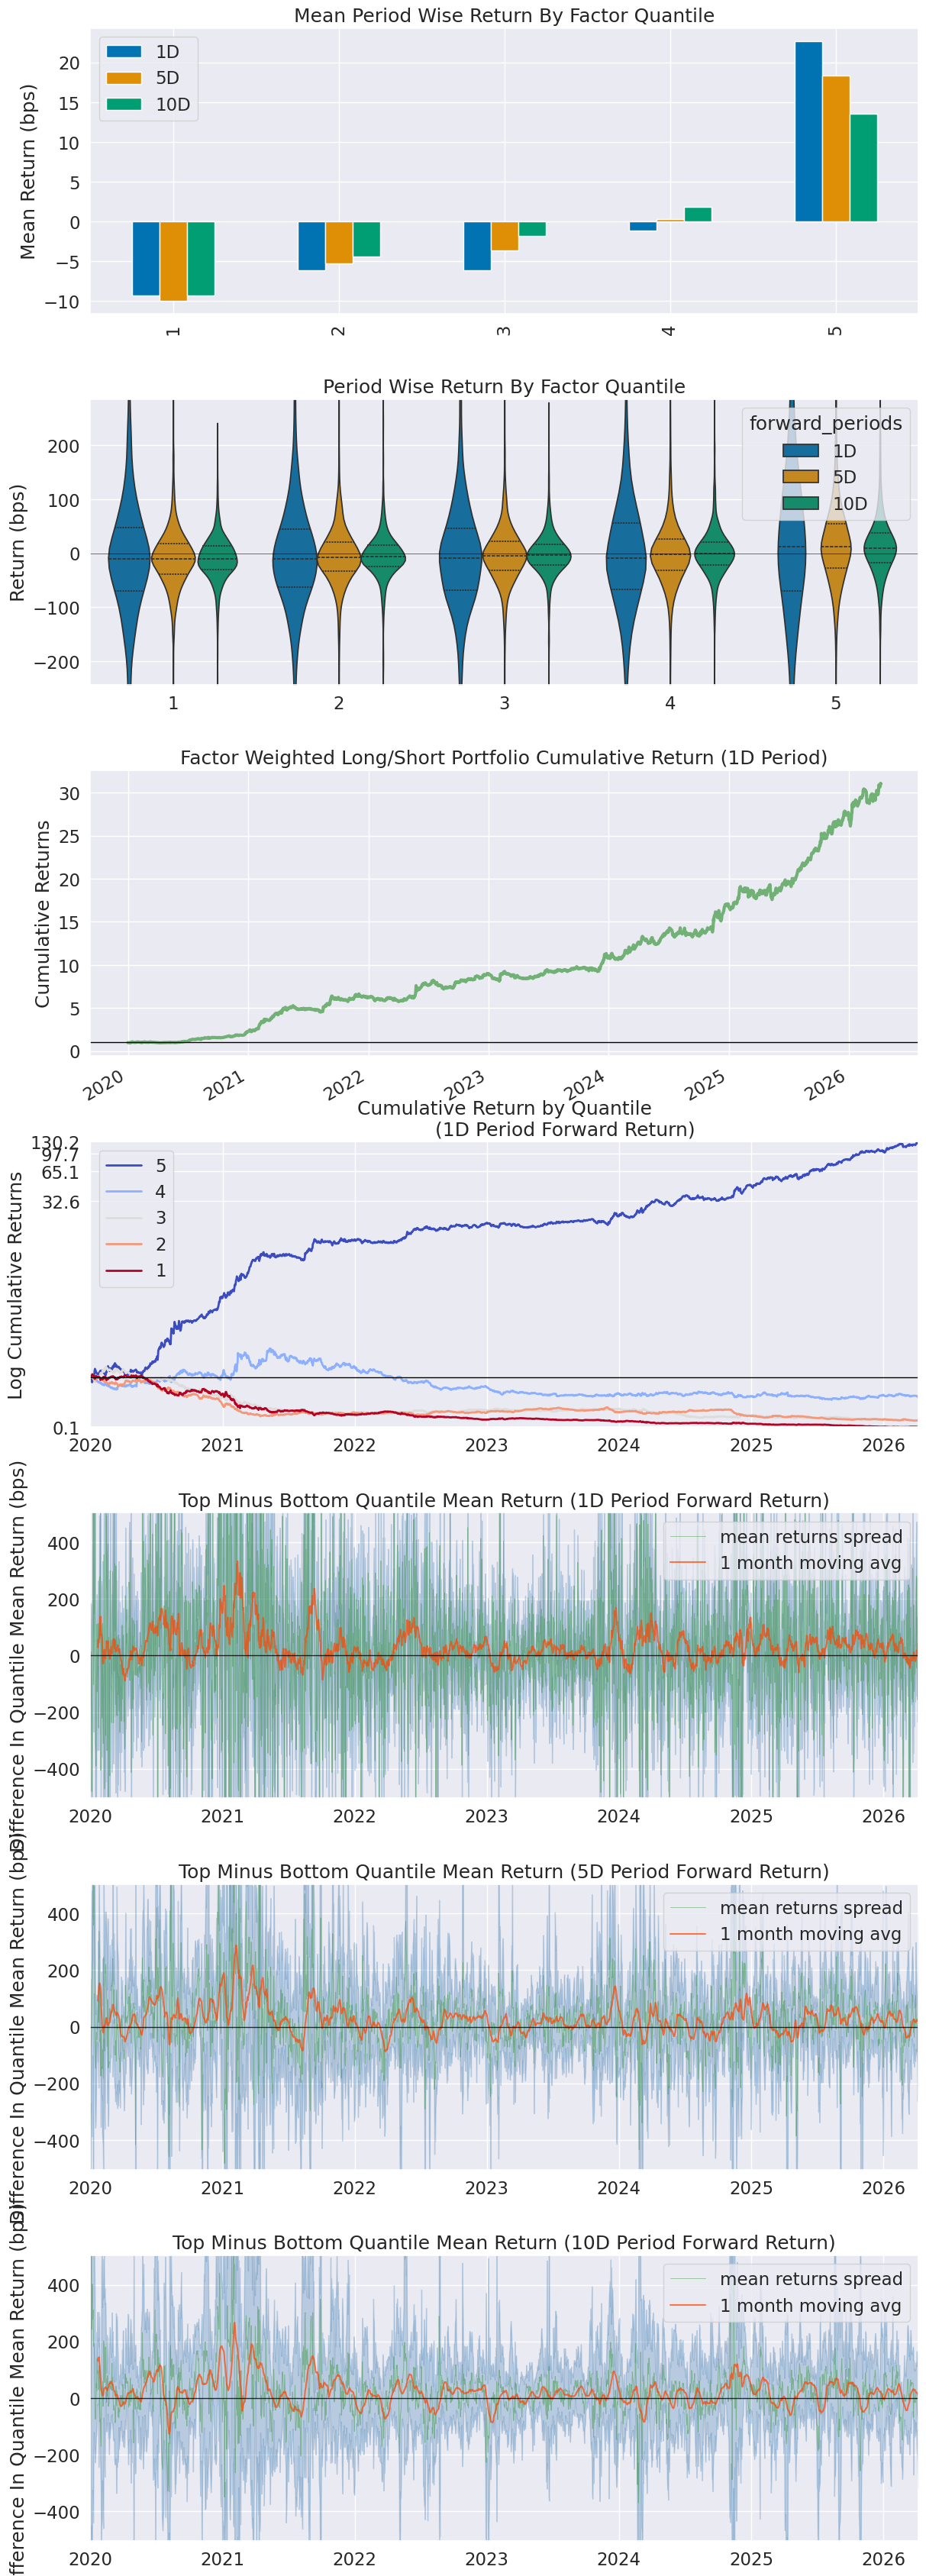

Information Analysis


,1D,5D,10D
IC Mean,-0.009,0.021,0.032
IC Std.,0.227,0.222,0.220
Risk-Adjusted IC,-0.041,0.093,0.145
t-stat(IC),-1.959,4.431,6.949
p-value(IC),0.050,0.000,0.000
IC Skew,-0.014,0.084,-0.026
IC Kurtosis,-0.232,-0.251,-0.173


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


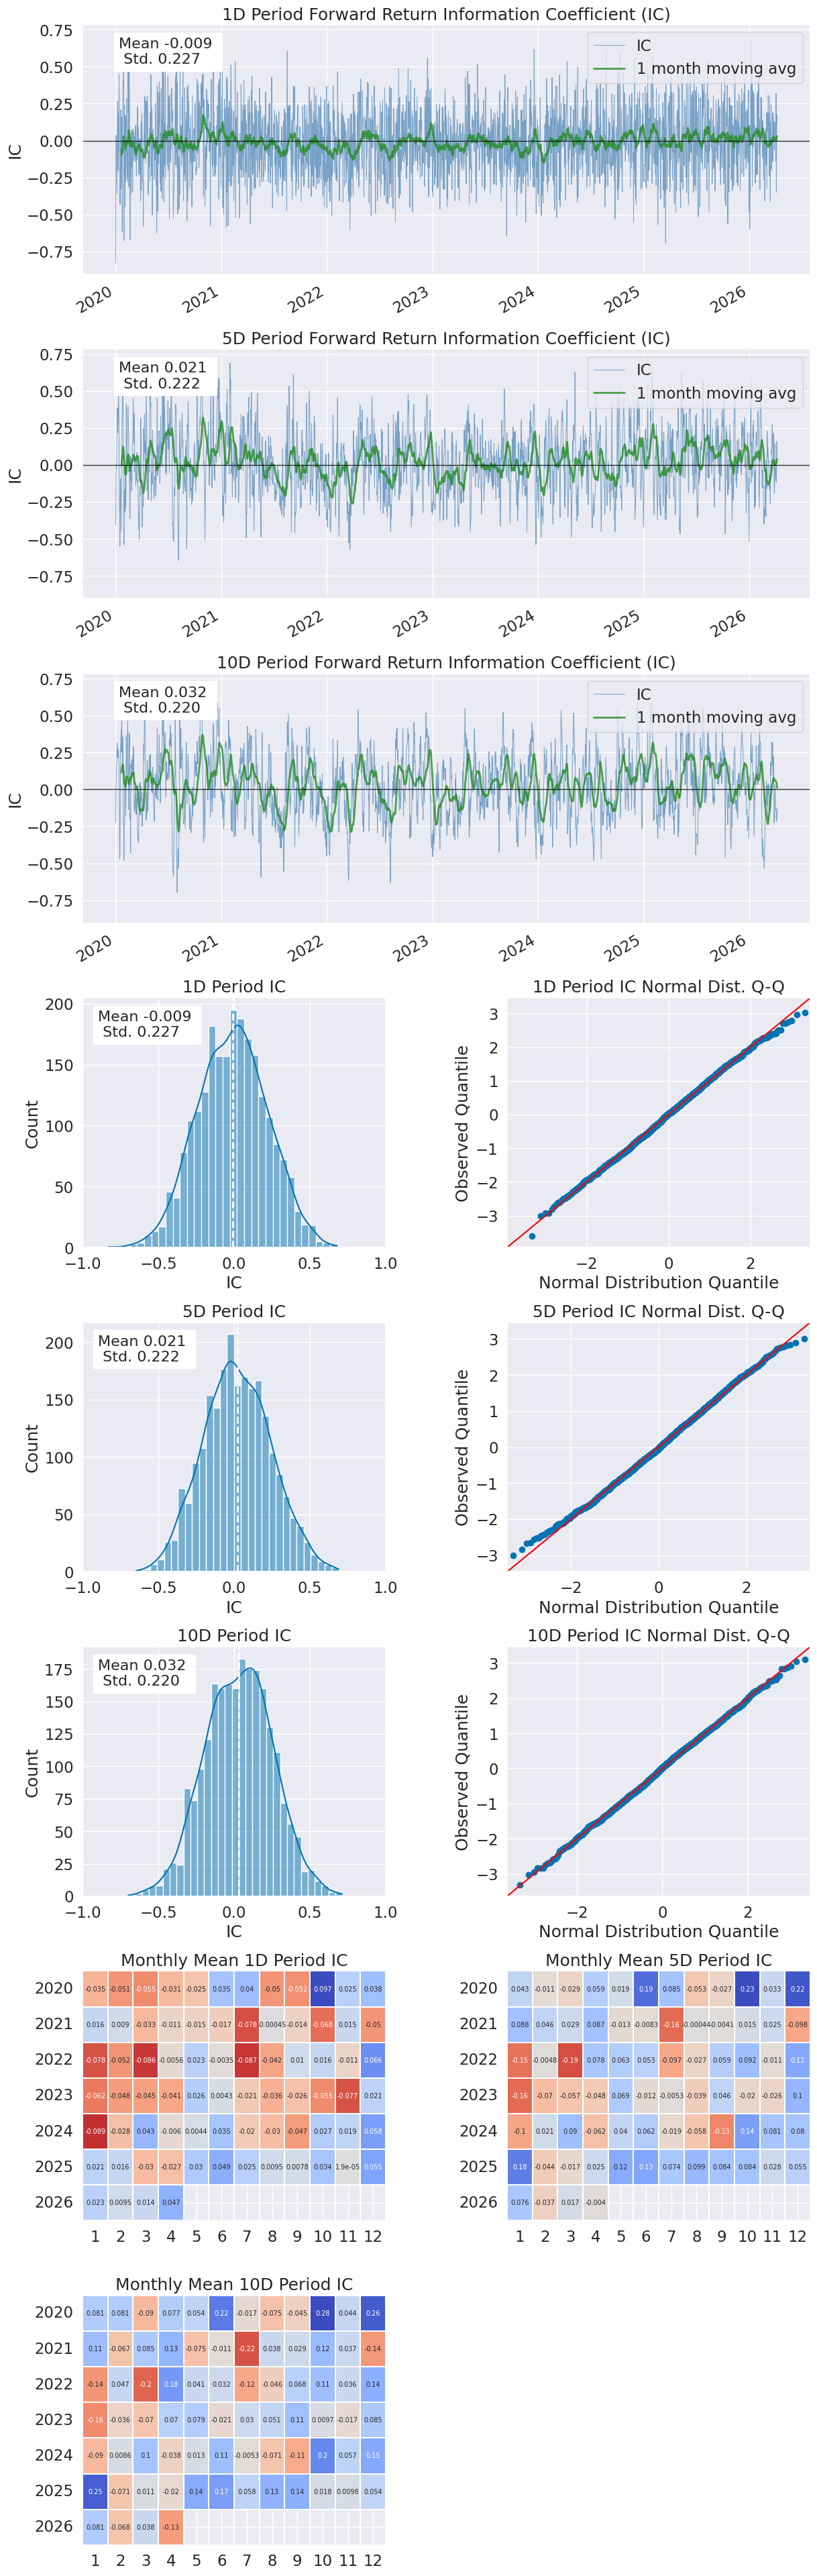

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.204,0.401,0.524
Quantile 2 Mean Turnover,0.410,0.629,0.703
Quantile 3 Mean Turnover,0.435,0.664,0.736
Quantile 4 Mean Turnover,0.384,0.631,0.715
Quantile 5 Mean Turnover,0.198,0.408,0.524


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.925,0.739,0.582


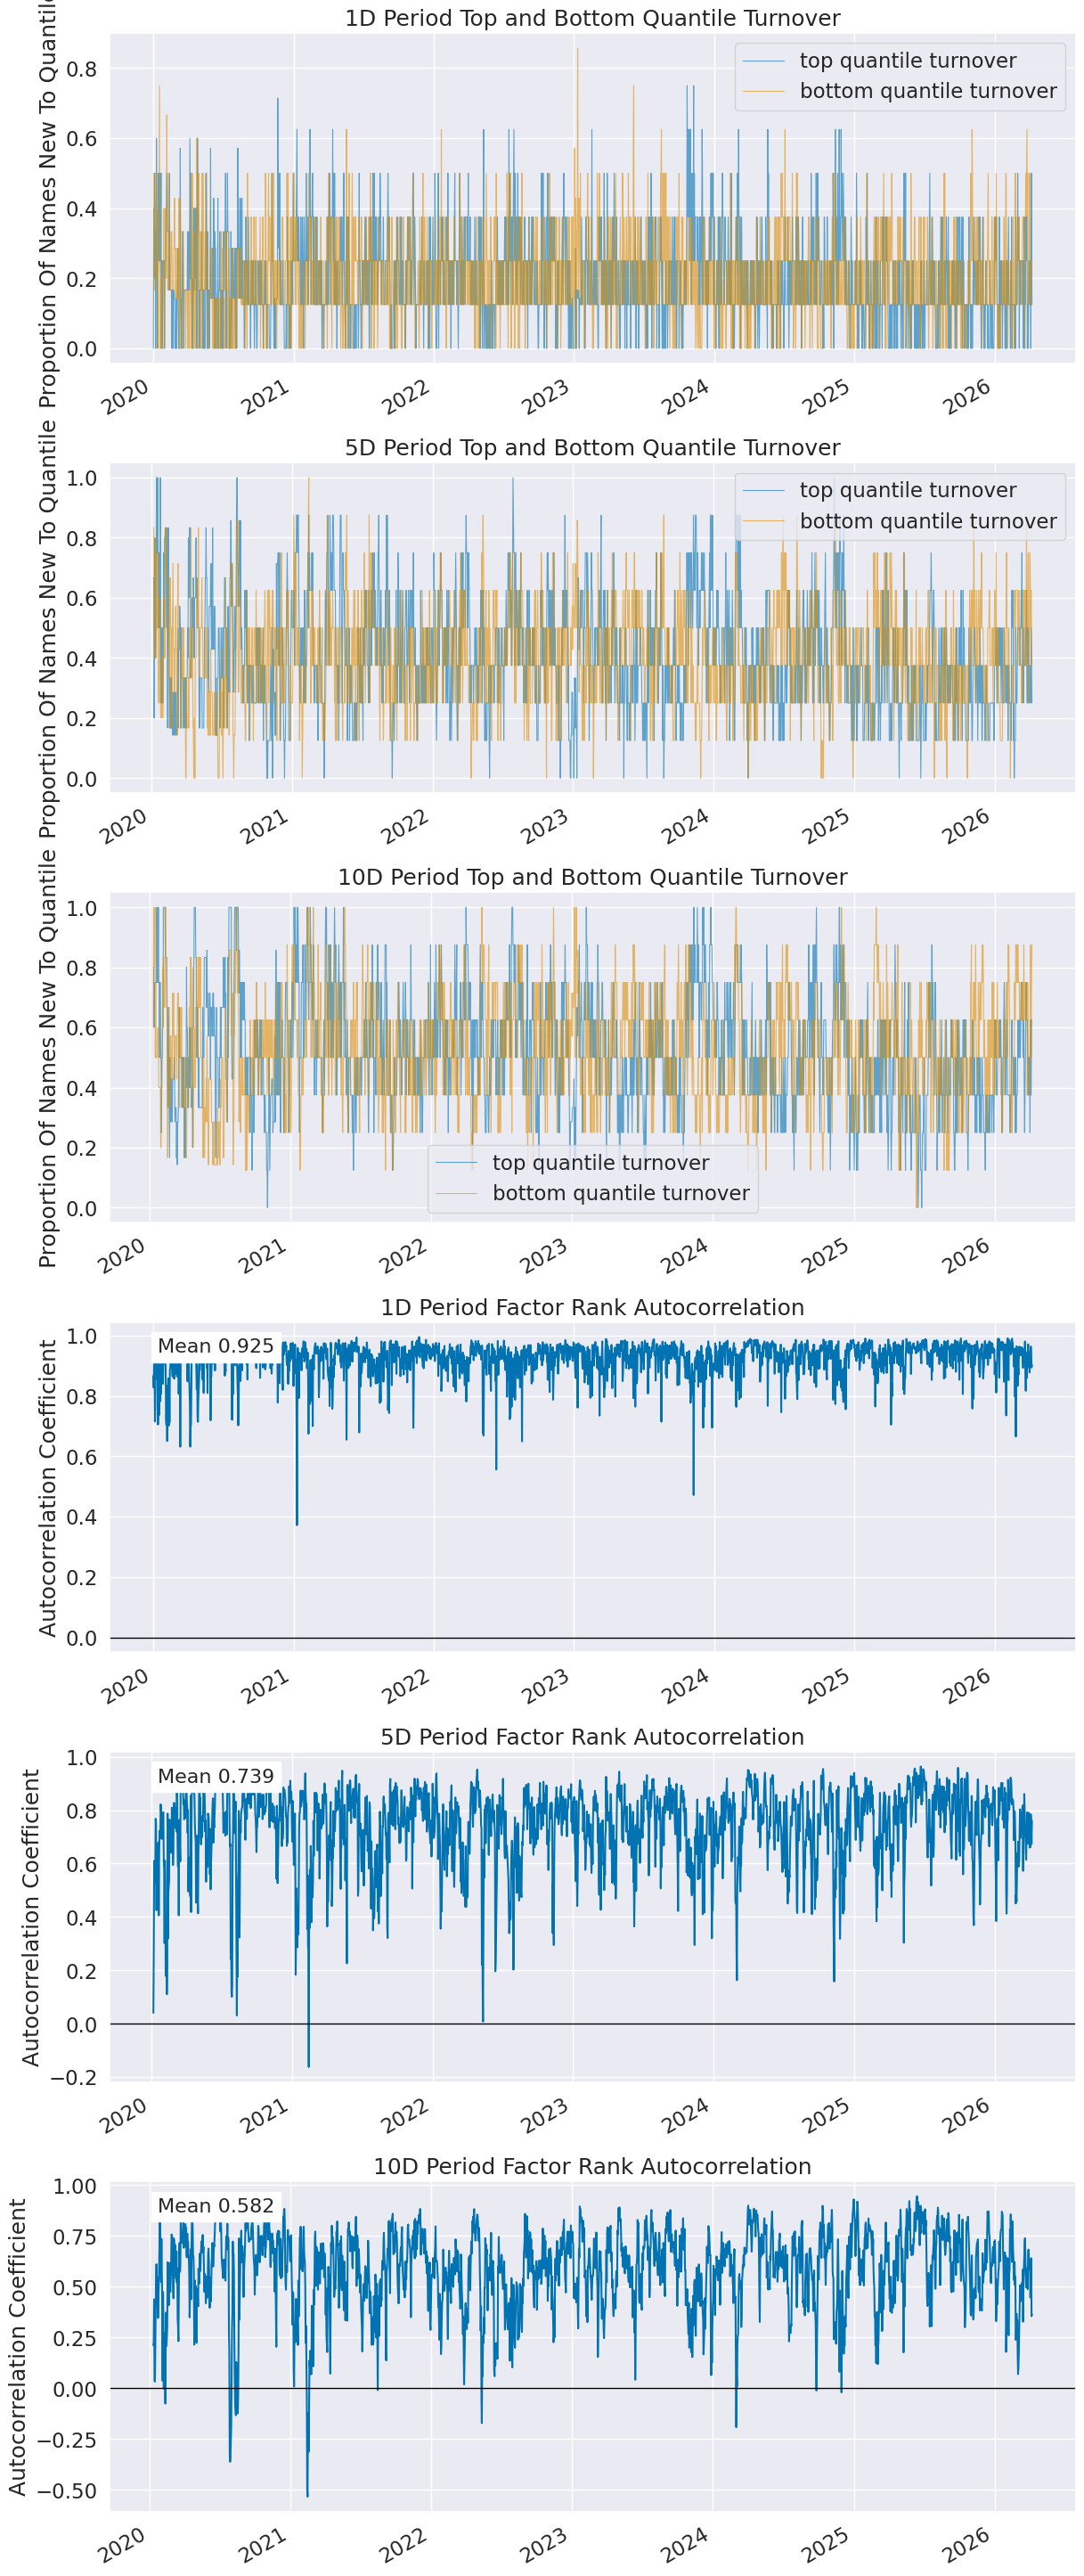

In [1]:
# AUTO-GENERATED by scripts/generate_factor_notebooks.py from
# scripts/factors_catalog.py -- do not edit by hand. Re-run the
# generator (or the "Generate Notebooks" workflow) to refresh.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Instantaneous Momentum -- portfolio instantaneous_momentum.40
portfolio = "instantaneous_momentum"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Restrict the analysis to the *dynamic* point-in-time universe rather than
# every ticker that was ever tradeable. get_historical_universe returns a
# boolean membership matrix (dates x tickers); masking the raw factor with it
# drops each asset on the days it was out of universe, so AlphaLens scores
# the factor on the universe we actually trade.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)